In [312]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree
from scipy.stats import pearsonr

In [313]:
df=pd.read_csv("train.csv")
df.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


In [314]:
df.shape

(3000, 23)

In [315]:
df.describe()

,id,budget,popularity,runtime,revenue
count,3000.000000,3.000000e+03,3000.000000,2998.000000,3.000000e+03
mean,1500.500000,2.253133e+07,8.463274,107.856571,6.672585e+07
std,866.169729,3.702609e+07,12.104000,22.086434,1.375323e+08
min,1.000000,0.000000e+00,0.000001,0.000000,1.000000e+00
25%,750.750000,0.000000e+00,4.018053,94.000000,2.379808e+06
50%,1500.500000,8.000000e+06,7.374861,104.000000,1.680707e+07
75%,2250.250000,2.900000e+07,10.890983,118.000000,6.891920e+07
max,3000.000000,3.800000e+08,294.337037,338.000000,1.519558e+09


In [316]:
df.describe(include='object')

,belongs_to_collection,genres,homepage,imdb_id,original_language,original_title,overview,poster_path,production_companies,production_countries,release_date,spoken_languages,status,tagline,title,Keywords,cast,crew
count,604,2993,946,3000,3000,3000,2992,2999,2844,2945,3000,2980,3000,2403,3000,2724,2987,2984
unique,422,872,941,3000,36,2975,2992,2999,2383,321,2398,401,2,2400,2969,2648,2975,2984
top,"[{'id': 645, 'name': 'James Bond Collection', ...","[{'id': 18, 'name': 'Drama'}]",http://www.transformersmovie.com/,tt2637294,en,Joshua,"When Lou, who has become the ""father of the In...",/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,"[{'name': 'Paramount Pictures', 'id': 4}]","[{'iso_3166_1': 'US', 'name': 'United States o...",9/10/10,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Based on a true story.,The Magnificent Seven,"[{'id': 10183, 'name': 'independent film'}]",[],"[{'credit_id': '59ac067c92514107af02c8c8', 'de..."
freq,16,266,4,1,2575,2,1,1,51,1752,5,1817,2996,3,2,27,13,1


In [317]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   belongs_to_collection  604 non-null    object 
 2   budget                 3000 non-null   int64  
 3   genres                 2993 non-null   object 
 4   homepage               946 non-null    object 
 5   imdb_id                3000 non-null   object 
 6   original_language      3000 non-null   object 
 7   original_title         3000 non-null   object 
 8   overview               2992 non-null   object 
 9   popularity             3000 non-null   float64
 10  poster_path            2999 non-null   object 
 11  production_companies   2844 non-null   object 
 12  production_countries   2945 non-null   object 
 13  release_date           3000 non-null   object 
 14  runtime                2998 non-null   float64
 15  spok

# Data preprocessing

In [318]:
df.columns

Index(['id', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'runtime', 'spoken_languages',
       'status', 'tagline', 'title', 'Keywords', 'cast', 'crew', 'revenue'],
      dtype='object')

## Missing Value Analysis

In [319]:
print(df.isnull().sum())

id                          0
belongs_to_collection    2396
budget                      0
genres                      7
homepage                 2054
imdb_id                     0
original_language           0
original_title              0
overview                    8
popularity                  0
poster_path                 1
production_companies      156
production_countries       55
release_date                0
runtime                     2
spoken_languages           20
status                      0
tagline                   597
title                       0
Keywords                  276
cast                       13
crew                       16
revenue                     0
dtype: int64


In [320]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0]) 

belongs_to_collection    79.866667
homepage                 68.466667
tagline                  19.900000
Keywords                  9.200000
production_companies      5.200000
production_countries      1.833333
spoken_languages          0.666667
crew                      0.533333
cast                      0.433333
overview                  0.266667
genres                    0.233333
runtime                   0.066667
poster_path               0.033333
dtype: float64


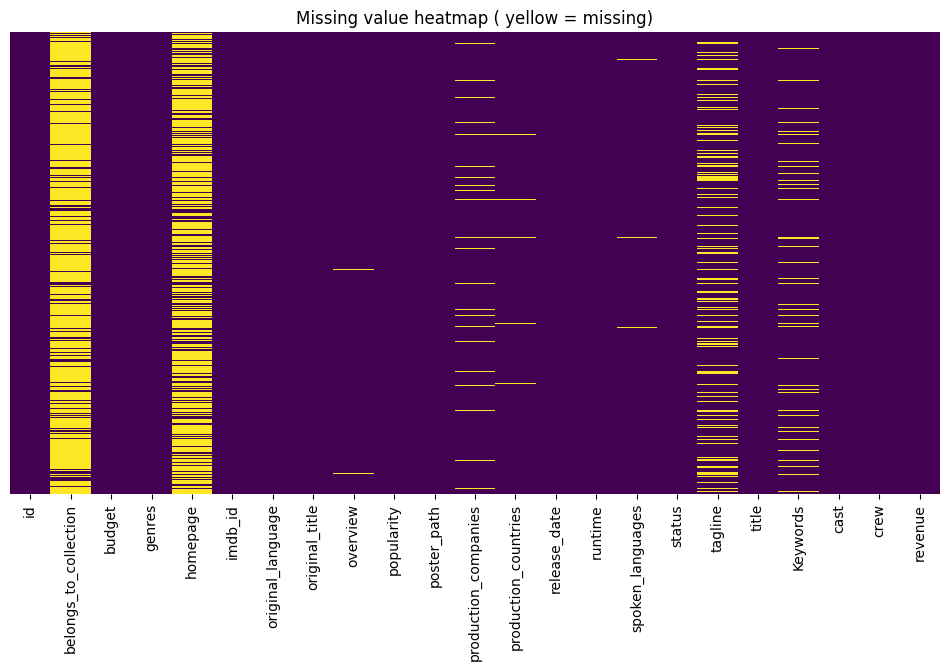

In [321]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    df.isnull(),          
    cbar=False,           
    yticklabels=False,    
    cmap='viridis'        
)
plt.title('Missing value heatmap ( yellow = missing)')
plt.show()

In [322]:
df['runtime'].fillna(df['runtime'].median(), inplace=True)

/var/folders/xw/5yjdwh314qq6ntp9fy6rpyfm0000gn/T/ipykernel_32932/530401232.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['runtime'].fillna(df['runtime'].median(), inplace=True)


## Duplicate

In [323]:
df.duplicated().sum()

np.int64(0)

In [324]:
print("Zero budget:", (df['budget'] == 0).sum())
print("Zero revenue:", (df['revenue'] == 0).sum())

Zero budget: 812
Zero revenue: 0


In [325]:
median = df.loc[df['budget']> 0, 'budget'].median()
df["budget"] = df["budget"].mask(df["budget"] == 0, median)

columns='id', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'runtime', 'spoken_languages',
       'status', 'tagline', 'title', 'Keywords', 'cast', 'crew', 'revenue'

In [326]:
df.iloc[0]

id                                                                       1
belongs_to_collection    [{'id': 313576, 'name': 'Hot Tub Time Machine ...
budget                                                            14000000
genres                                      [{'id': 35, 'name': 'Comedy'}]
homepage                                                               NaN
imdb_id                                                          tt2637294
original_language                                                       en
original_title                                      Hot Tub Time Machine 2
overview                 When Lou, who has become the "father of the In...
popularity                                                        6.575393
poster_path                               /tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg
production_companies     [{'name': 'Paramount Pictures', 'id': 4}, {'na...
production_countries     [{'iso_3166_1': 'US', 'name': 'United States o...
release_date             

In [327]:
df['belongs_to_collection'].iloc[0]

"[{'id': 313576, 'name': 'Hot Tub Time Machine Collection', 'poster_path': '/iEhb00TGPucF0b4joM1ieyY026U.jpg', 'backdrop_path': '/noeTVcgpBiD48fDjFVic1Vz7ope.jpg'}]"

In [328]:
df['belongs_to_collection'].values

array(["[{'id': 313576, 'name': 'Hot Tub Time Machine Collection', 'poster_path': '/iEhb00TGPucF0b4joM1ieyY026U.jpg', 'backdrop_path': '/noeTVcgpBiD48fDjFVic1Vz7ope.jpg'}]",
       "[{'id': 107674, 'name': 'The Princess Diaries Collection', 'poster_path': '/wt5AMbxPTS4Kfjx7Fgm149qPfZl.jpg', 'backdrop_path': '/zSEtYD77pKRJlUPx34BJgUG9v1c.jpg'}]",
       nan, ..., nan, nan, nan], dtype=object)

In [329]:
df['genres'].values

array(["[{'id': 35, 'name': 'Comedy'}]",
       "[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10751, 'name': 'Family'}, {'id': 10749, 'name': 'Romance'}]",
       "[{'id': 18, 'name': 'Drama'}]", ...,
       "[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name': 'Action'}, {'id': 9648, 'name': 'Mystery'}, {'id': 53, 'name': 'Thriller'}]",
       "[{'id': 35, 'name': 'Comedy'}, {'id': 10749, 'name': 'Romance'}]",
       "[{'id': 53, 'name': 'Thriller'}, {'id': 28, 'name': 'Action'}, {'id': 9648, 'name': 'Mystery'}]"],
      dtype=object)

In [330]:
df['production_companies'].iloc[0]

"[{'name': 'Paramount Pictures', 'id': 4}, {'name': 'United Artists', 'id': 60}, {'name': 'Metro-Goldwyn-Mayer (MGM)', 'id': 8411}]"

In [331]:
def extract_collection_features(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            return pd.Series([None])
    
    
    if isinstance(x, list) and len(x) > 0:
        return pd.Series([                    
            x[0].get('name')       
        ])
    
    return pd.Series([None])

column created:has_collection

In [332]:
df['collection_name']=df['belongs_to_collection'].apply(extract_collection_features)

In [333]:
df['has_collection'] = df['collection_name'].apply(lambda x: 1 if x!=None  else 0)

In [334]:
def extract_names(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            return []
    
    if isinstance(x, list):
        return [i.get('name') for i in x if isinstance(i, dict) and 'name' in i]
    
    return []

In [335]:
df['genres_list']=df['genres'].apply(extract_names)

In [336]:
df['genre_count'] = df['genres_list'].apply(len)

In [337]:
df['has_homepage'] = df['homepage'].notnull().astype(int)

In [338]:
df['original_language'].value_counts()

original_language
en    2575
fr      78
ru      47
es      43
hi      42
ja      37
it      24
cn      20
ko      20
zh      19
de      18
ta      16
sv       8
nl       6
pt       6
fa       5
da       5
ro       4
hu       3
tr       3
no       2
ml       2
pl       2
te       2
fi       2
ur       1
he       1
el       1
ar       1
nb       1
vi       1
mr       1
cs       1
sr       1
bn       1
id       1
Name: count, dtype: int64

In [339]:
top_langs = df['original_language'].value_counts().index[:5]

df['original_language'] = df['original_language'].apply(
    lambda x: x if x in top_langs else 'other'
)

In [340]:
df['is_english'] = df['original_language'].apply(lambda x: 1 if x == 'en' else 0)

In [341]:
df = pd.get_dummies(df, columns=['original_language'], drop_first=True,dtype=int)

In [342]:
df['overview_length'] = df['overview'].fillna('').apply(len)
df['overview_word_count'] = df['overview'].fillna('').apply(lambda x: len(x.split()))

In [343]:
df['company_names'] = df['production_companies'].apply(extract_names)

In [344]:
all_companies = df['company_names'].explode()

freq = all_companies.value_counts()

df['company_score'] = df['company_names'].apply(
    lambda x: sum(freq.get(i, 0) for i in x)
)

In [345]:
freq

company_names
Warner Bros.                              202
Universal Pictures                        188
Paramount Pictures                        161
Twentieth Century Fox Film Corporation    138
Columbia Pictures                          91
                                         ... 
Videofilms                                  1
Riofilm                                     1
Zero Gravity Management                     1
Pierce/Williams Entertainment               1
Quick Six Entertainment                     1
Name: count, Length: 3695, dtype: int64

In [346]:
top_company=['Warner Bros.','Universal Pictures','Paramount Pictures','Twentieth Century Fox Film Corporation']

In [347]:
def is_top_company(companies):
    if isinstance(companies, list):
        return int(any(c in top_company for c in companies))
    return 0

In [348]:
df['is_top_company'] = df['company_names'].apply(is_top_company)

In [349]:
def top_company_score(company):
    if not isinstance(company, list):
        return 0
    return sum(c in top_company for c in company[:5])

In [350]:
df['top_company_score'] = df['company_names'].apply(top_company_score)

In [351]:
df['country_names'] = df['production_countries'].apply(extract_names)

In [352]:
def is_usa(country_list):
    if not isinstance(country_list, list):
        return 0
    return int('United States of America' in country_list)

df['usa_produced'] = df['country_names'].apply(is_usa)

In [353]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_dayofweek'] = df['release_date'].dt.dayofweek

df["season"] = df["release_month"]%4

/var/folders/xw/5yjdwh314qq6ntp9fy6rpyfm0000gn/T/ipykernel_32932/644218548.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')


In [354]:
df['spoken_languages_name']=df['spoken_languages'].apply(extract_names)

In [355]:
df['num_spoken_languages'] = df['spoken_languages_name'].apply(lambda x: len(x))

In [356]:
df['spoken_languages_name'].value_counts()

spoken_languages_name
[English]                                                1817
[English, Español]                                         86
[English, Français]                                        77
[Pусский]                                                  45
[Français]                                                 40
                                                         ... 
[العربية, English, Français, Italiano]                      1
[Český, Deutsch]                                            1
[English, Français, Italiano, Pусский, Español]             1
[اردو]                                                      1
[български език, English, Français, Pусский, Español]       1
Name: count, Length: 392, dtype: int64

In [357]:
def is_english(languages):
    if not isinstance(languages, list):
        return 0
    return int('English' in languages)

In [358]:
df['has_english'] = df['spoken_languages_name'].apply(is_english)

In [359]:
df['has_keywords'] = df['Keywords'].apply(lambda x: 1 if type(x) == str else 0)

In [360]:
df['keyword_names'] = df['Keywords'].apply(extract_names)

In [361]:
all_keywords = df['keyword_names'].explode()
freq = all_keywords.value_counts()

df['keyword_score'] = df['keyword_names'].apply(
    lambda x: sum(freq.get(i, 0) for i in x)
)

In [362]:
df['cast_names'] = df['cast'].apply(extract_names)

In [363]:
all_cast = df['cast_names'].explode()

In [364]:
freq = all_cast.value_counts()

df['cast_score'] = df['cast_names'].apply(
    lambda x: sum(freq.get(i, 0) for i in x)
)

In [365]:
def extract_director(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            return None
    
    if isinstance(x, list):
        for i in x:
            if isinstance(i, dict) and i.get('job') == 'Director':
                return i.get('name')   # ✅ string
    
    return None

In [366]:
df['director'] = df['crew'].apply(extract_director)

In [367]:
freq = df['director'].value_counts()
df['director_score'] = df['director'].map(freq)

In [368]:
df.drop(columns=['belongs_to_collection','id','collection_name','genres_list','genres','homepage', 'imdb_id','original_title','overview','poster_path','production_companies','company_names','production_countries', 'release_date','status','tagline','title','keyword_names','Keywords','cast_names','country_names','spoken_languages_name','cast','crew','director','spoken_languages',], inplace=True)

In [369]:
df.head()

,budget,popularity,runtime,revenue,has_collection,genre_count,has_homepage,is_english,original_language_es,original_language_fr,...,release_year,release_month,release_dayofweek,season,num_spoken_languages,has_english,has_keywords,keyword_score,cast_score,director_score
0,14000000,6.575393,93.0,12314651,1,1,0,1,0,0,...,2015,2,4,2,1,1,1,227,101,3.0
1,40000000,8.248895,113.0,95149435,1,4,0,1,0,0,...,2004,8,4,0,1,1,1,34,95,6.0
2,3300000,64.299990,105.0,13092000,0,1,1,1,0,0,...,2014,10,4,2,1,1,1,161,108,1.0
3,1200000,3.174936,122.0,16000000,0,2,1,0,0,0,...,2012,3,4,3,2,1,1,49,11,1.0
4,16000000,1.148070,118.0,3923970,0,2,0,0,0,0,...,2009,2,3,2,1,0,0,0,5,1.0


# EDA

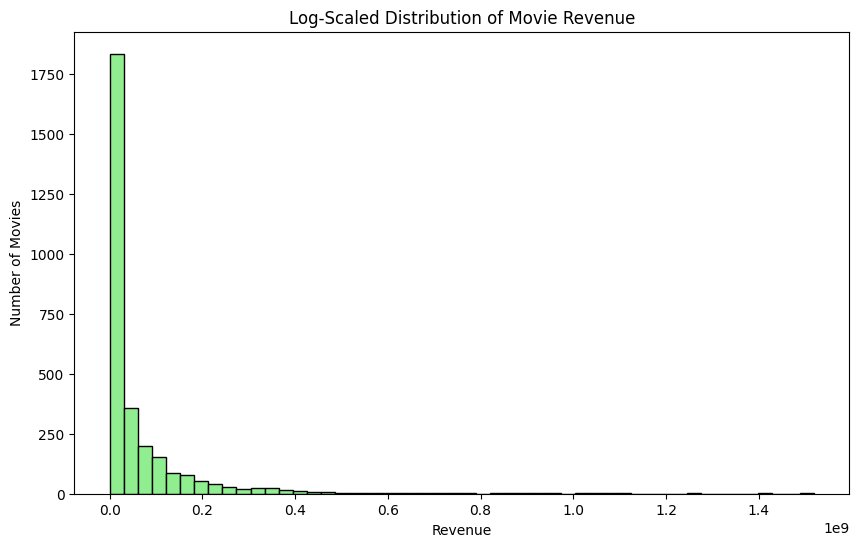

In [370]:
# revenue histogram
plt.figure(figsize=(10,6))
plt.hist(df['revenue'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Log-Scaled Distribution of Movie Revenue')
plt.xlabel('Revenue')
plt.ylabel('Number of Movies')
plt.show()

● Majority of movies have moderate to high revenue
● Few movies have very low revenue, which appear as a small tail on the left side of the histogram

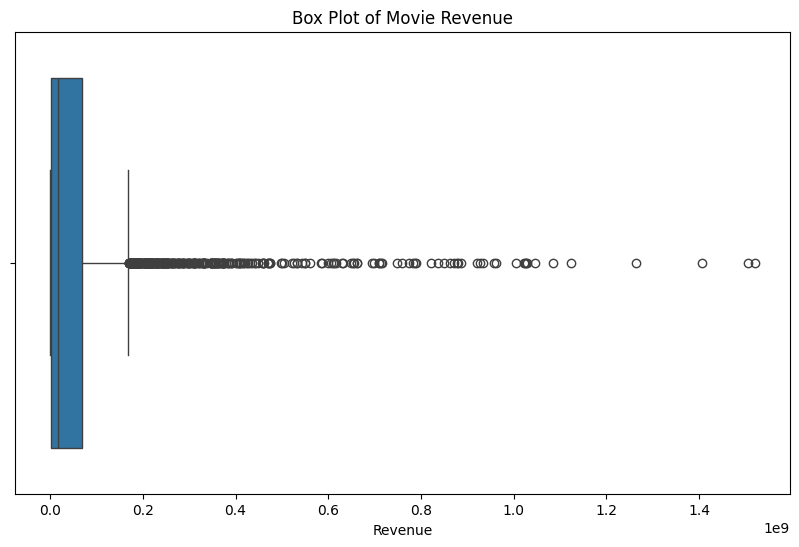

In [371]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['revenue'])  # log1p avoids log(0)
plt.xlabel('Revenue')
plt.title('Box Plot of Movie Revenue')
plt.show()

# Univariate Analysis 

In [372]:
df.columns

Index(['budget', 'popularity', 'runtime', 'revenue', 'has_collection',
       'genre_count', 'has_homepage', 'is_english', 'original_language_es',
       'original_language_fr', 'original_language_hi',
       'original_language_other', 'original_language_ru', 'overview_length',
       'overview_word_count', 'company_score', 'is_top_company',
       'top_company_score', 'usa_produced', 'release_year', 'release_month',
       'release_dayofweek', 'season', 'num_spoken_languages', 'has_english',
       'has_keywords', 'keyword_score', 'cast_score', 'director_score'],
      dtype='object')

'budget', 'popularity', 'runtime', 'revenue', 'has_collection',
       'genre_count', 'has_homepage', 'is_english', 'original_language_es',
       'original_language_fr', 'original_language_hi',
       'original_language_other', 'original_language_ru', 'overview_length',
       'overview_word_count', 'company_score', 'is_top_company',
       'top_company_score', 'usa_produced', 'release_year', 'release_month',
       'release_dayofweek', 'season', 'num_spoken_languages', 'has_english',
       'has_keywords', 'keyword_score', 'cast_score', 'director_score'],
      dtype='object'

# Summary Statistics

In [373]:
# Numerical summary
num_cols = ['budget','popularity','runtime','revenue','overview_length','genre_count',
            'overview_word_count','company_score','top_company_score', 'director_score','keyword_score','cast_score','director_score']
df[num_cols].describe()

,budget,popularity,runtime,revenue,overview_length,genre_count,overview_word_count,company_score,top_company_score,director_score,keyword_score,cast_score,director_score
count,3.000000e+03,3000.000000,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2984.000000,3000.000000,3000.000000,2984.000000
mean,2.686200e+07,8.463274,107.854000,6.672585e+07,307.805667,2.503667,52.535333,66.811667,0.229000,2.534853,117.632667,69.977000,2.534853
std,3.501810e+07,12.104000,22.079293,1.375323e+08,167.023568,1.117021,28.383328,78.081900,0.423421,2.009563,119.550968,51.426919,2.009563
min,1.000000e+00,0.000001,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,9.000000e+06,4.018053,94.000000,2.379808e+06,178.000000,2.000000,31.000000,4.000000,0.000000,1.000000,28.000000,31.000000,1.000000
50%,1.600000e+07,7.374861,104.000000,1.680707e+07,285.000000,2.000000,49.000000,30.000000,0.000000,2.000000,82.000000,60.000000,2.000000
75%,2.900000e+07,10.890983,118.000000,6.891920e+07,395.250000,3.000000,68.000000,102.000000,0.000000,3.000000,175.000000,96.000000,3.000000
max,3.800000e+08,294.337037,338.000000,1.519558e+09,1007.000000,7.000000,177.000000,375.000000,2.000000,11.000000,1259.000000,461.000000,11.000000


In [374]:
cat_cols = ['has_collection','has_homepage','is_english','original_language_es','original_language_fr',
            'original_language_hi','original_language_other','original_language_ru','is_top_company','usa_produced','has_english','has_keywords']

df[cat_cols].describe()

,has_collection,has_homepage,is_english,original_language_es,original_language_fr,original_language_hi,original_language_other,original_language_ru,is_top_company,usa_produced,has_english,has_keywords
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.201333,0.315333,0.858333,0.014333,0.026000,0.01400,0.071667,0.015667,0.228333,0.760667,0.872667,0.908000
std,0.401063,0.464726,0.348766,0.118881,0.159162,0.11751,0.257978,0.124203,0.419829,0.426748,0.333402,0.289074
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


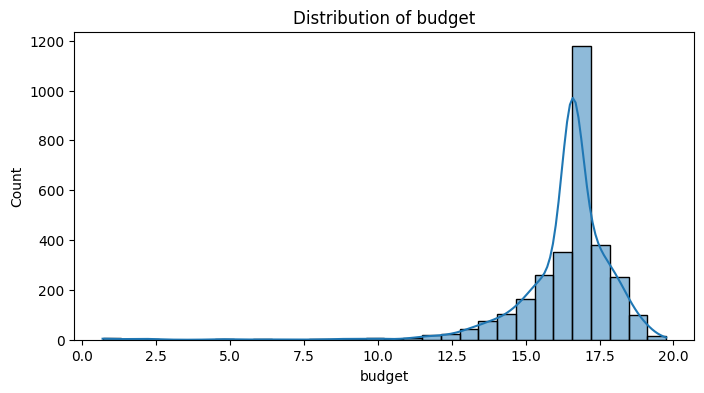

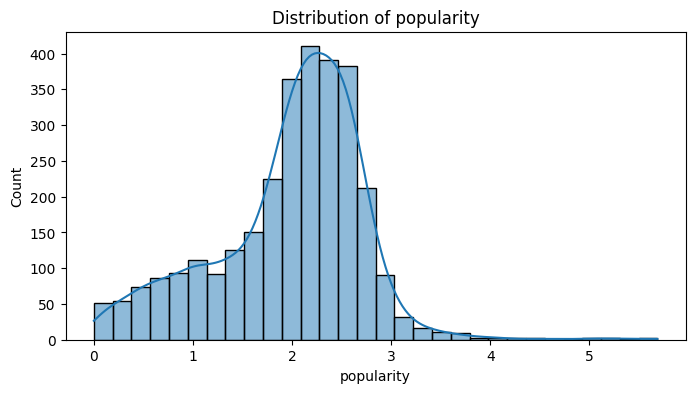

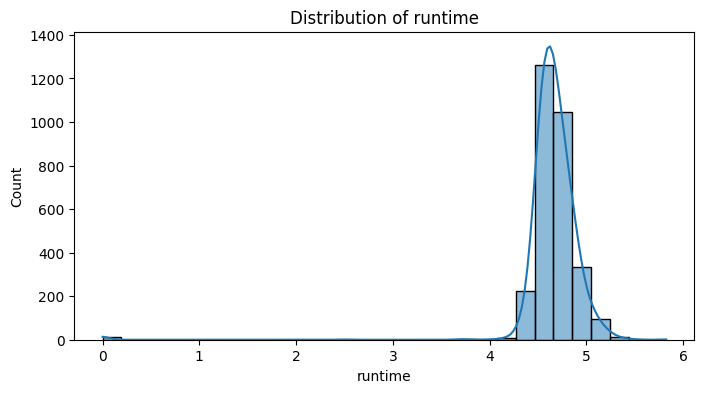

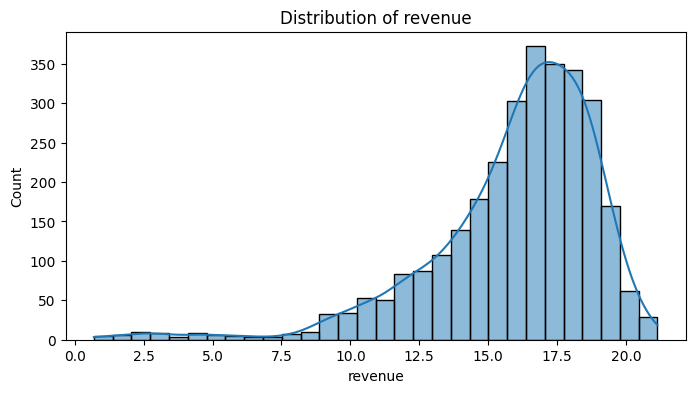

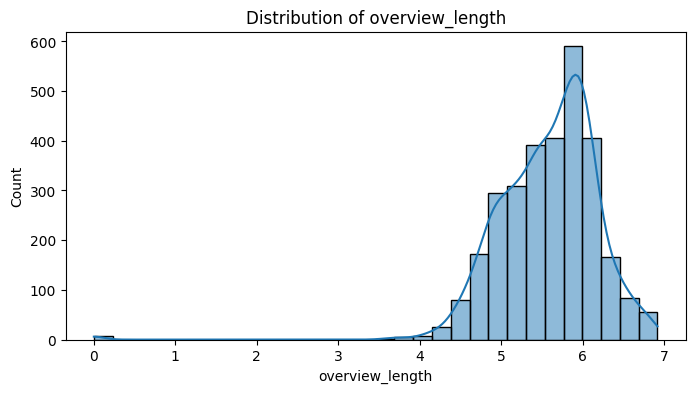

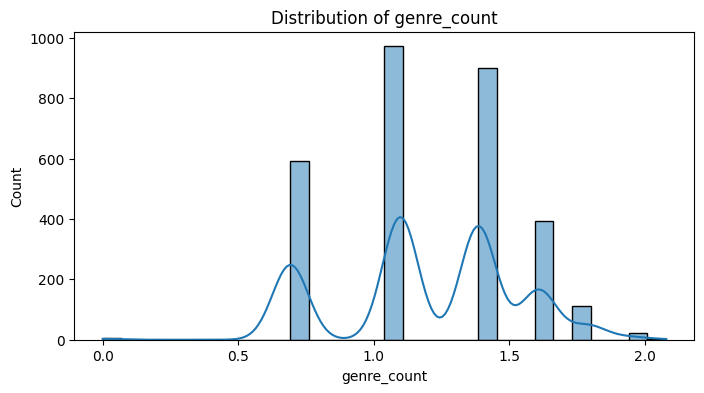

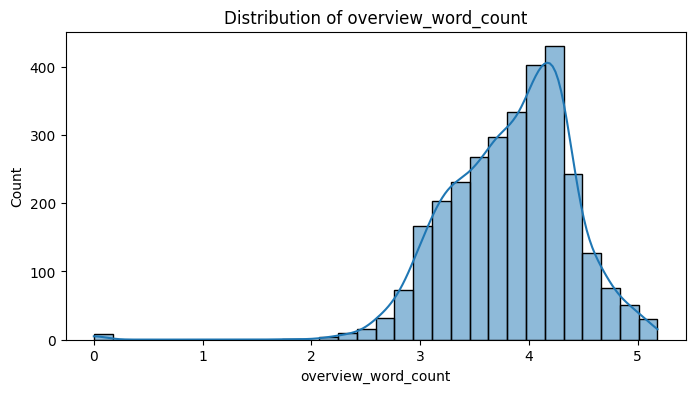

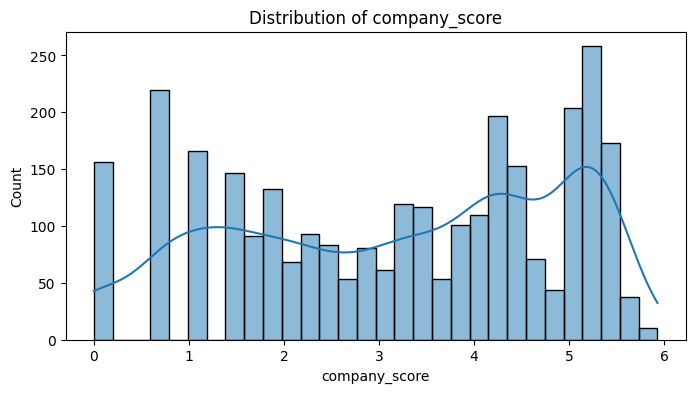

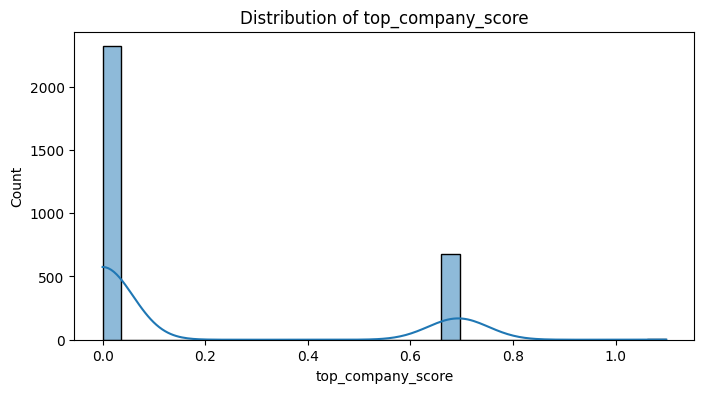

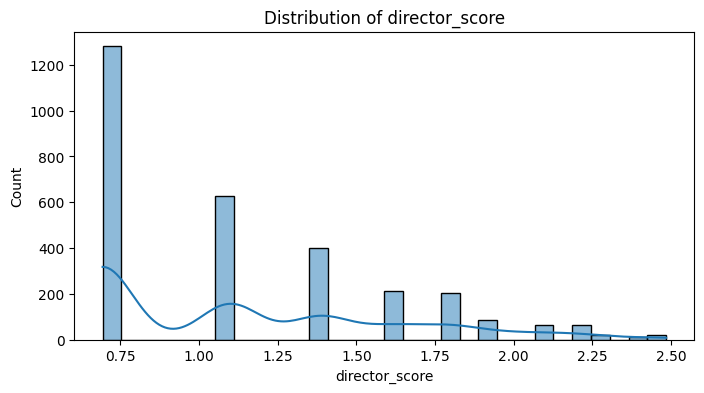

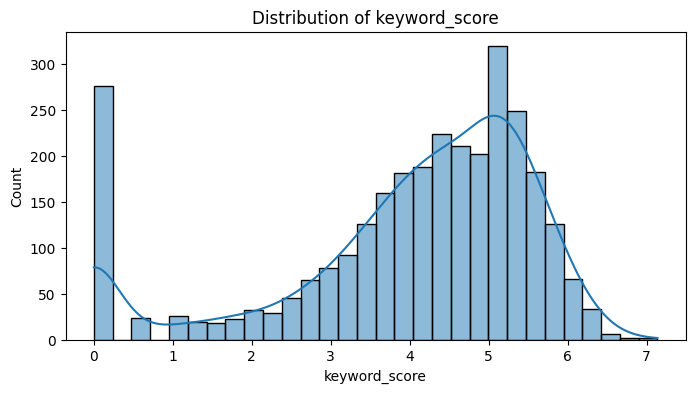

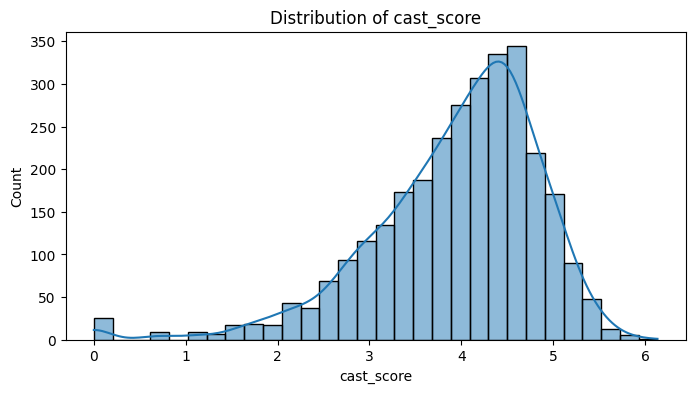

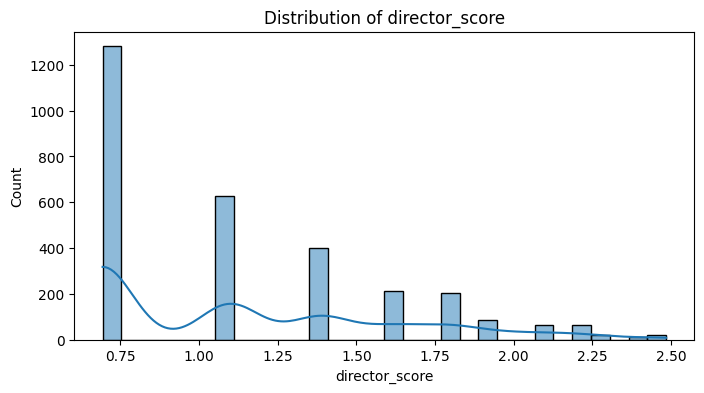

In [375]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(np.log1p(df[col]), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

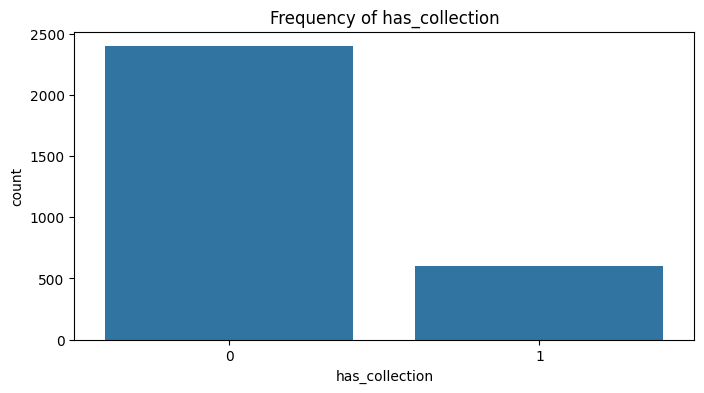

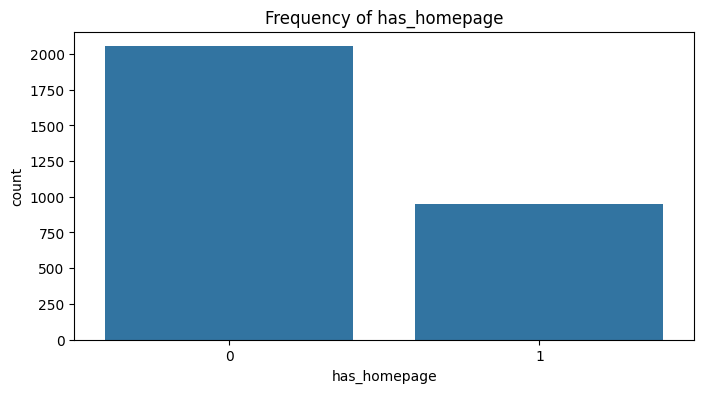

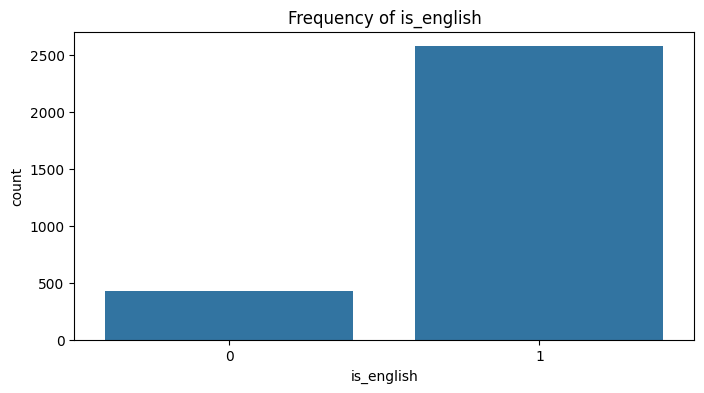

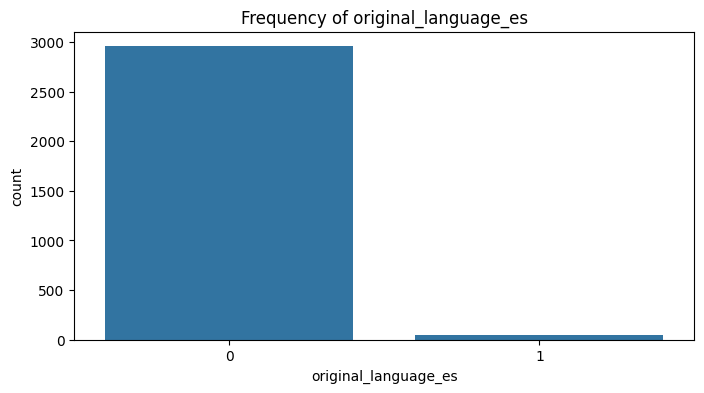

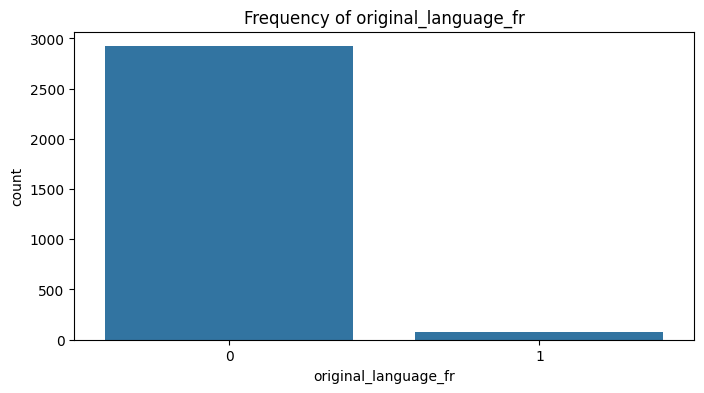

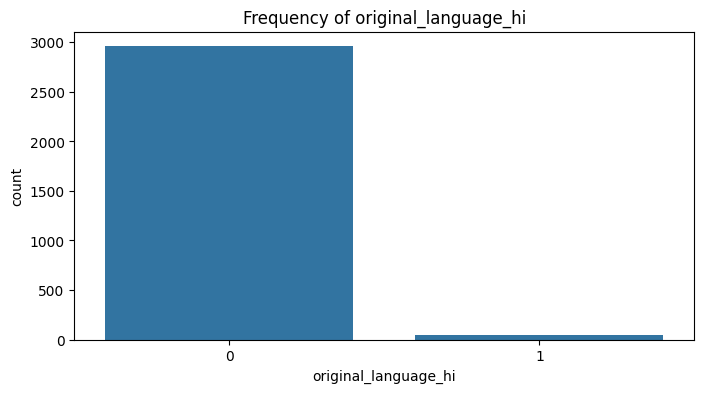

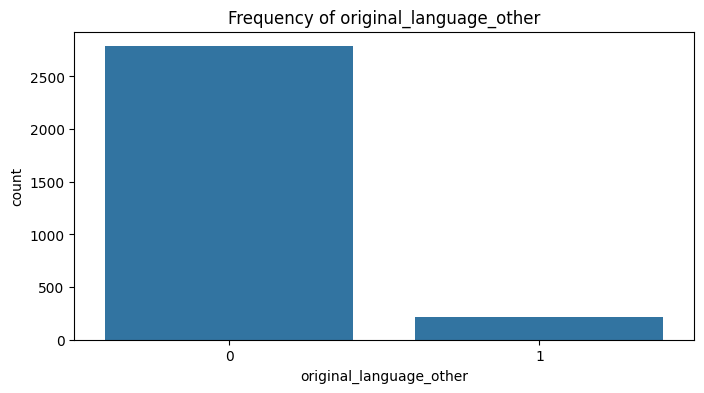

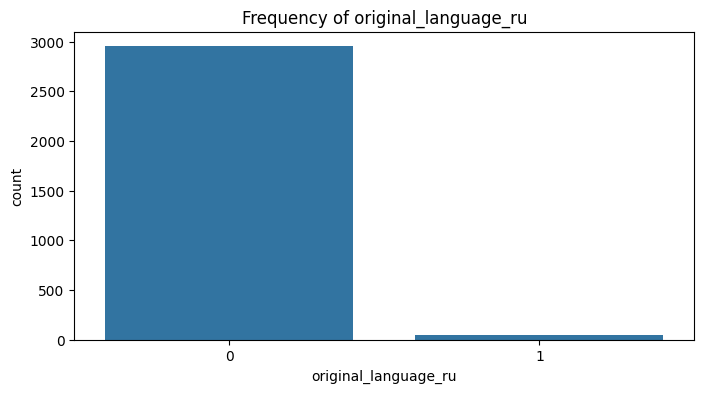

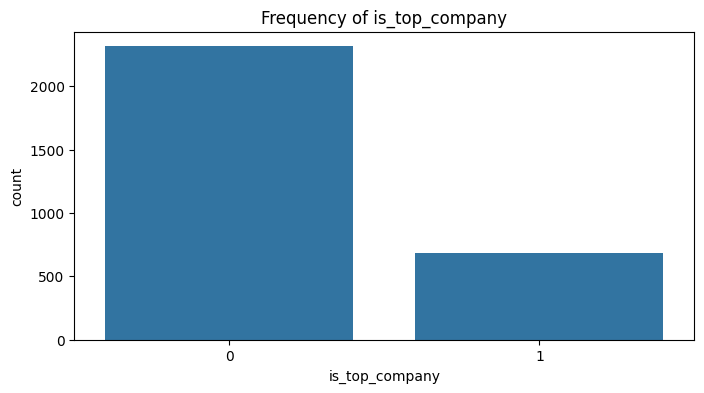

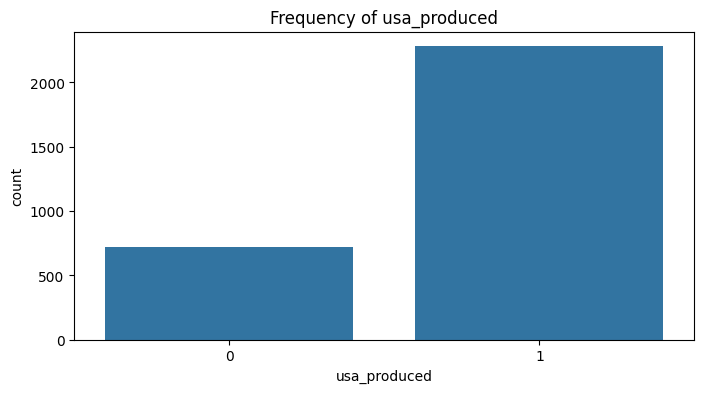

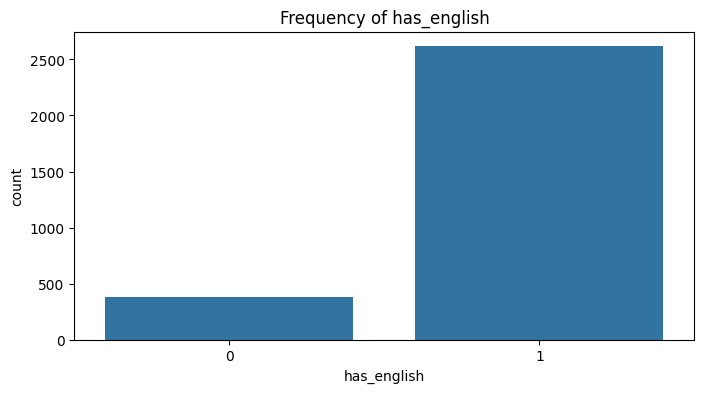

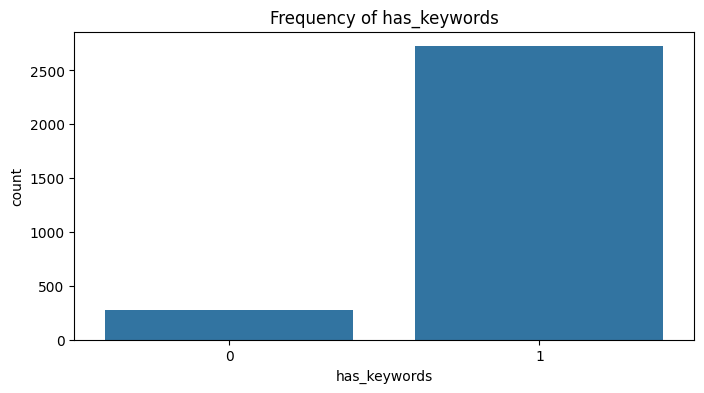

In [376]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.title(f'Frequency of {col}')
    plt.show()

# Bivariate Analysis 

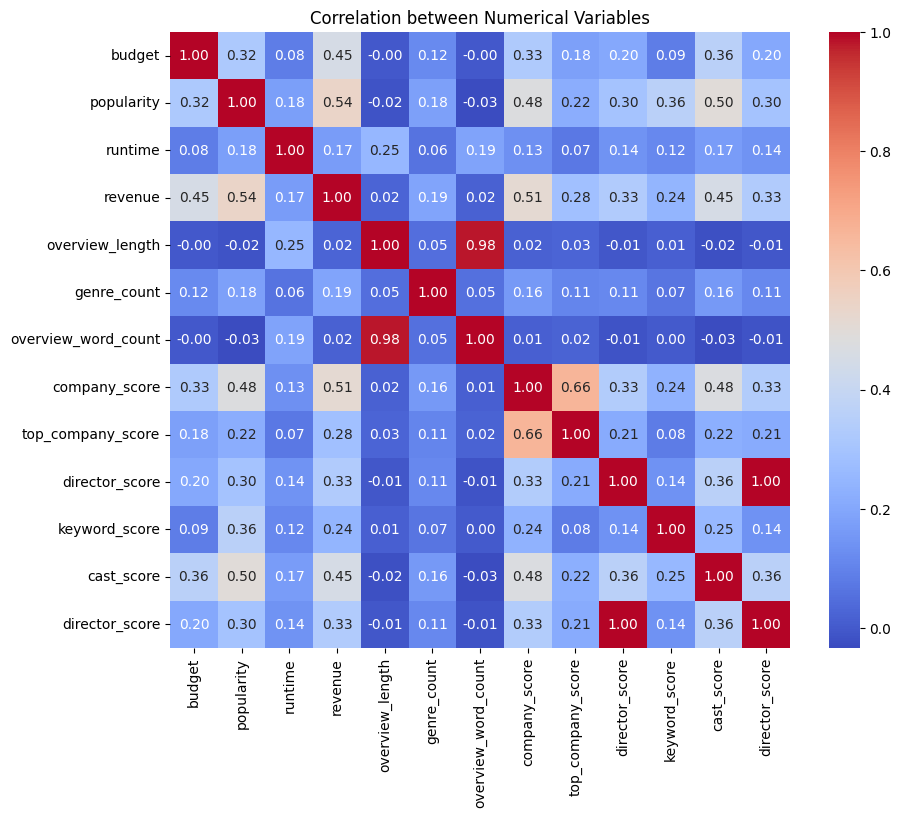

In [377]:
plt.figure(figsize=(10,8))
sns.heatmap( np.log1p(df[num_cols]).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between Numerical Variables")
plt.show()

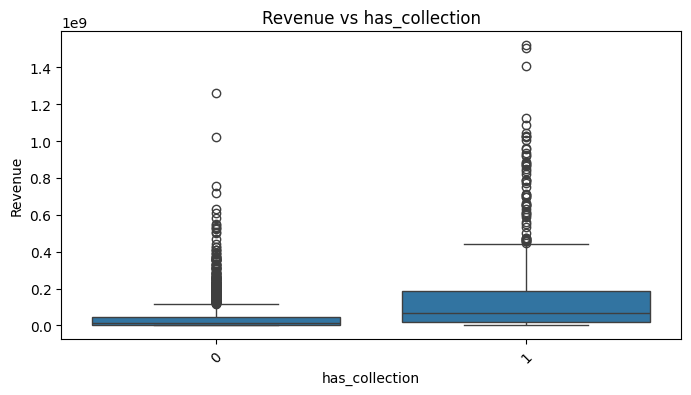

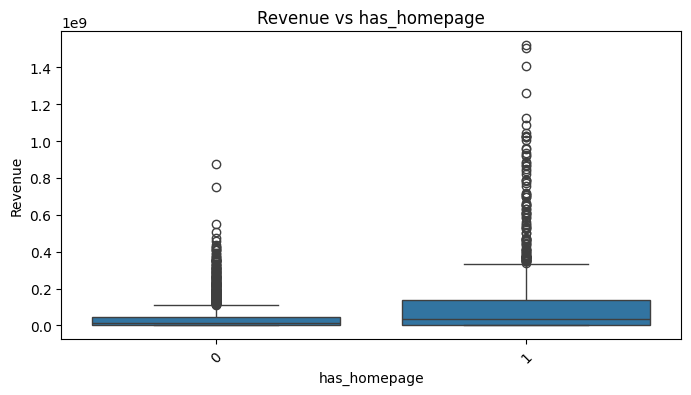

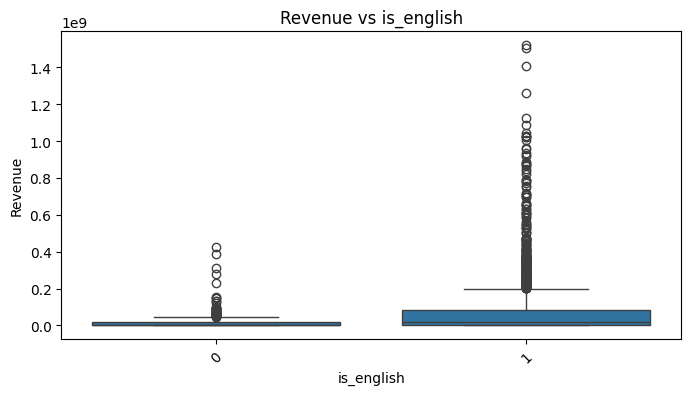

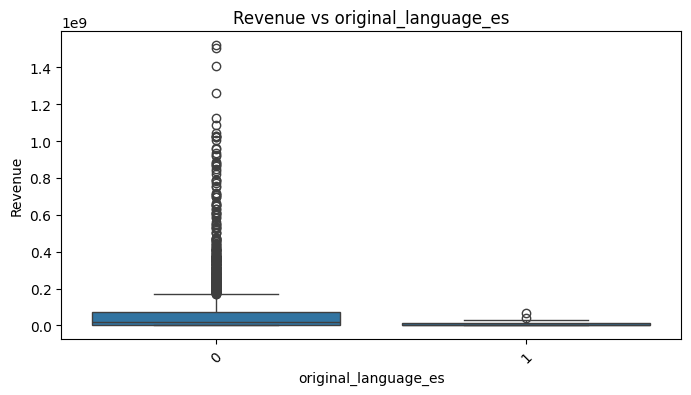

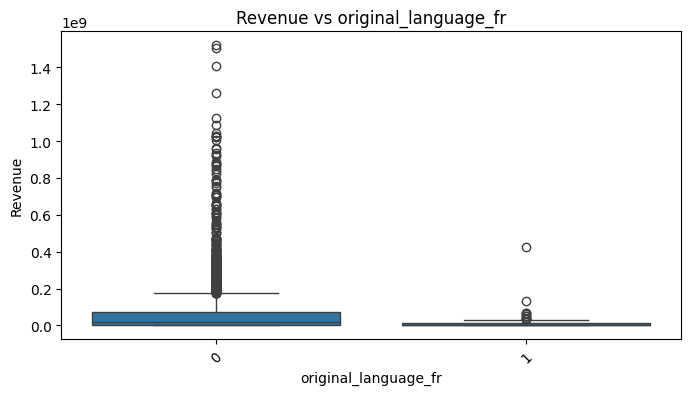

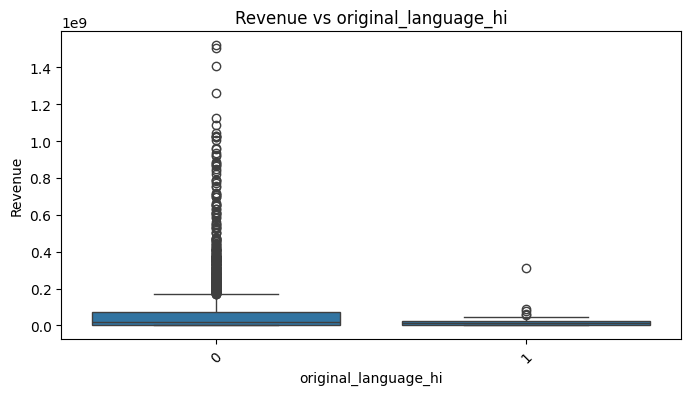

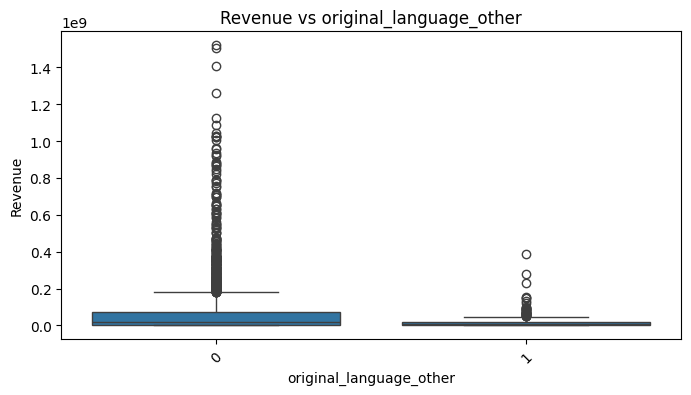

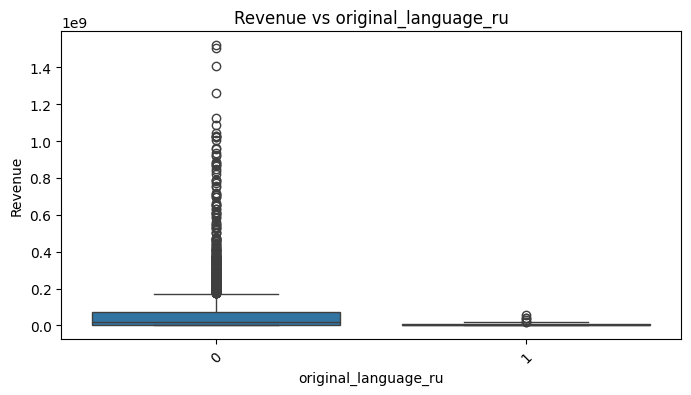

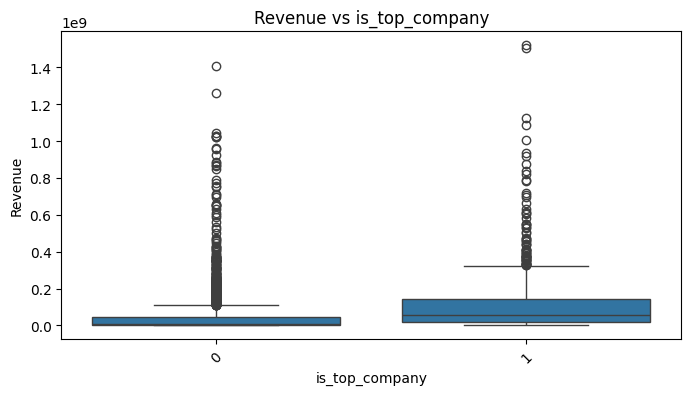

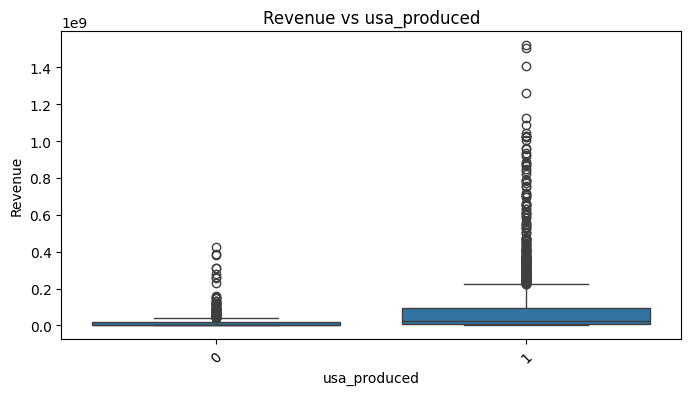

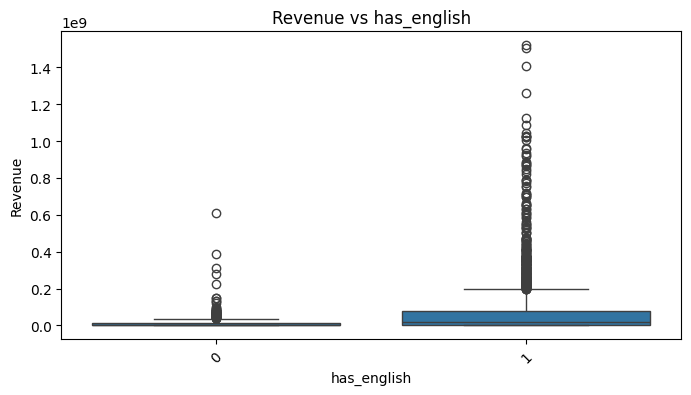

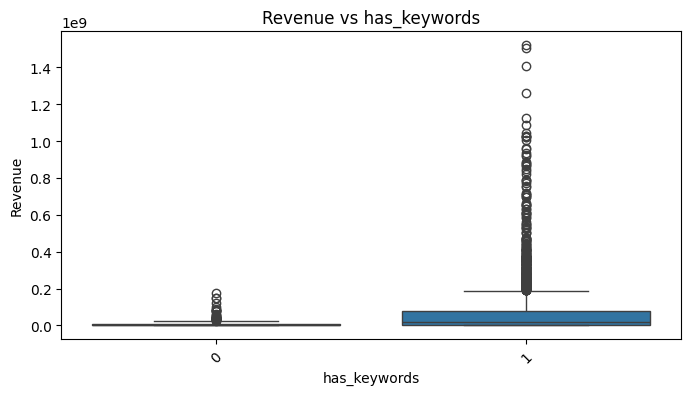

In [378]:
target = 'revenue'

for col in cat_cols:
    plt.figure(figsize=(8,4))
    # Use log scale for skewed revenue
    sns.boxplot(x=col, y=df[target], data=df)
    plt.title(f'Revenue vs {col}')
    plt.ylabel('Revenue')
    plt.xticks(rotation=45)
    plt.show()

In [379]:
subset_cols = ['budget','popularity','company_score','revenue','cast_score','director_score']

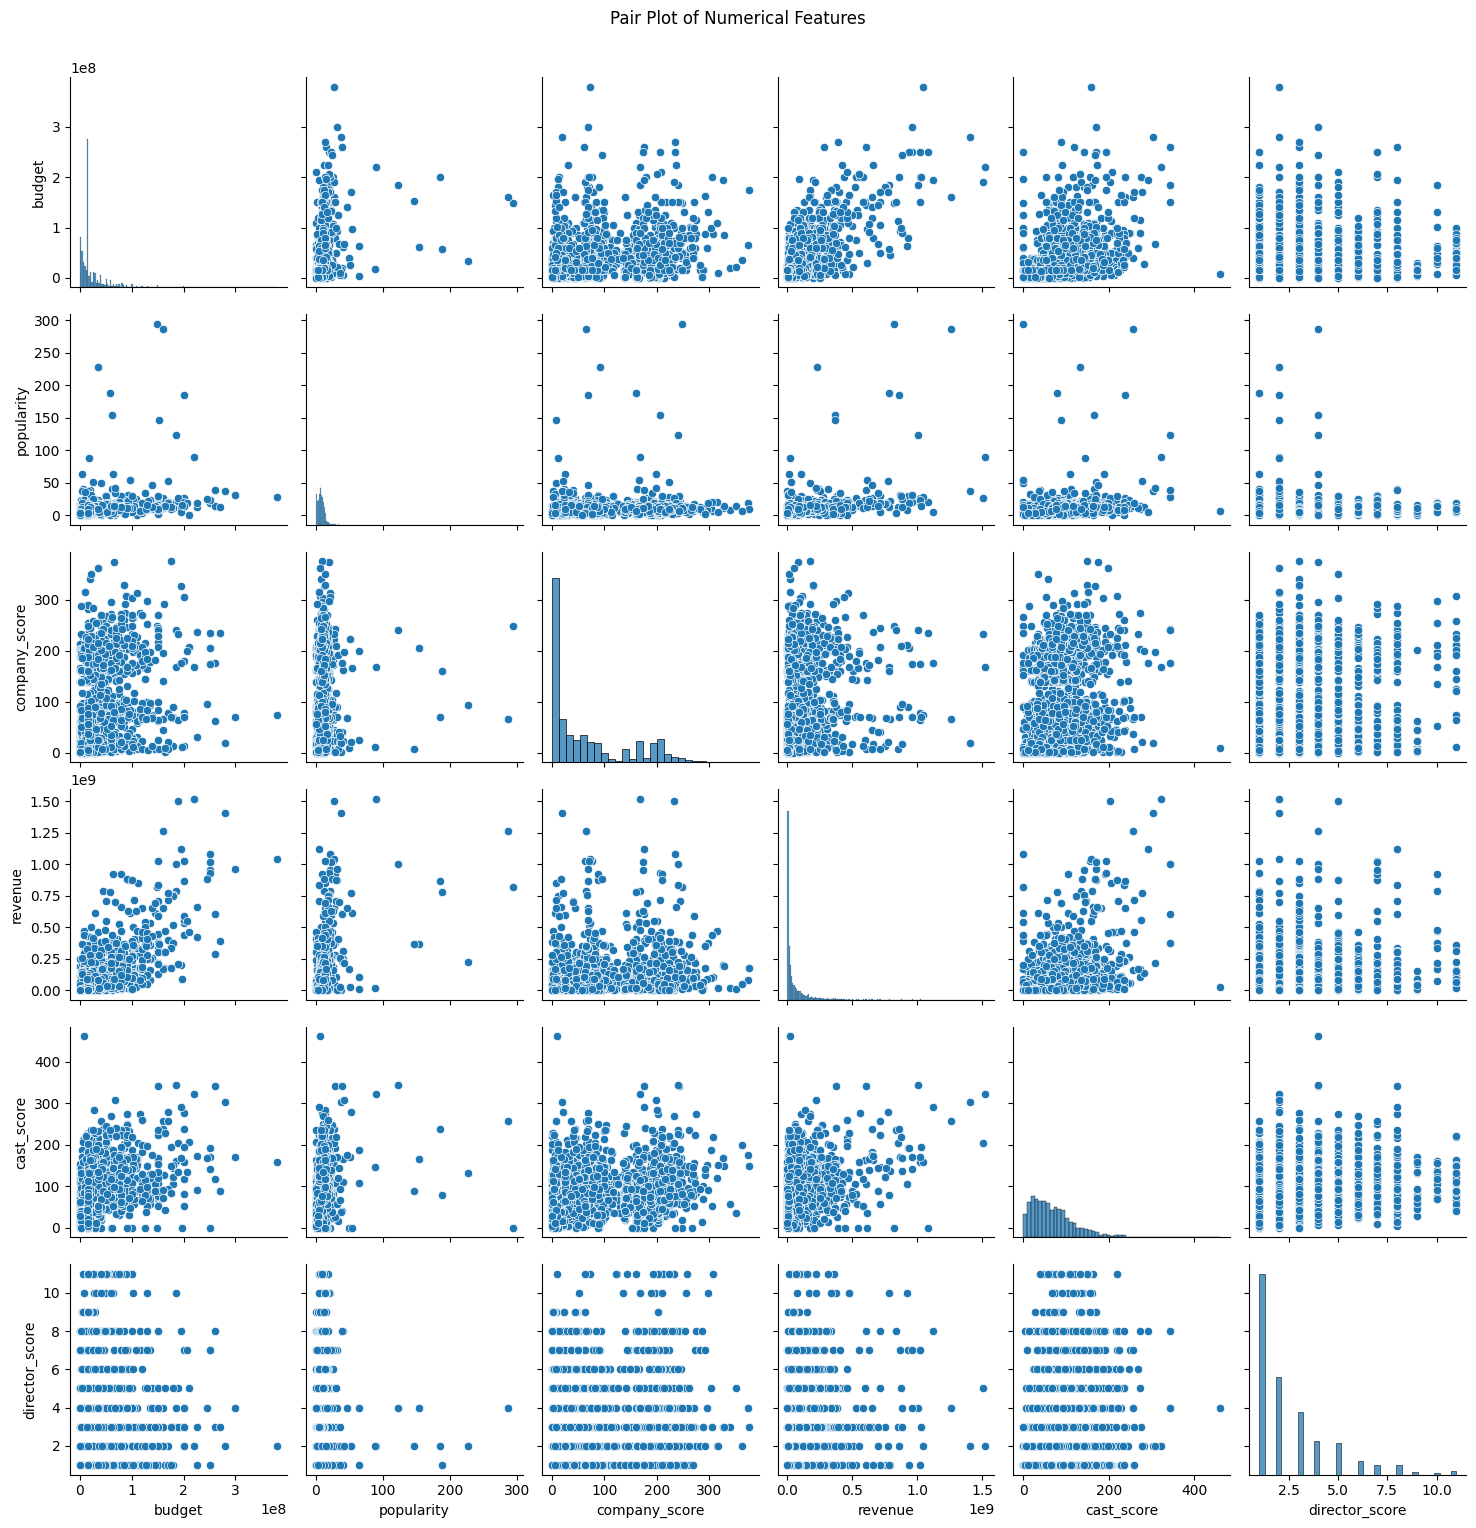

In [380]:
sns.pairplot(df[subset_cols])
plt.suptitle("Pair Plot of Numerical Features", y=1.02)
plt.show()

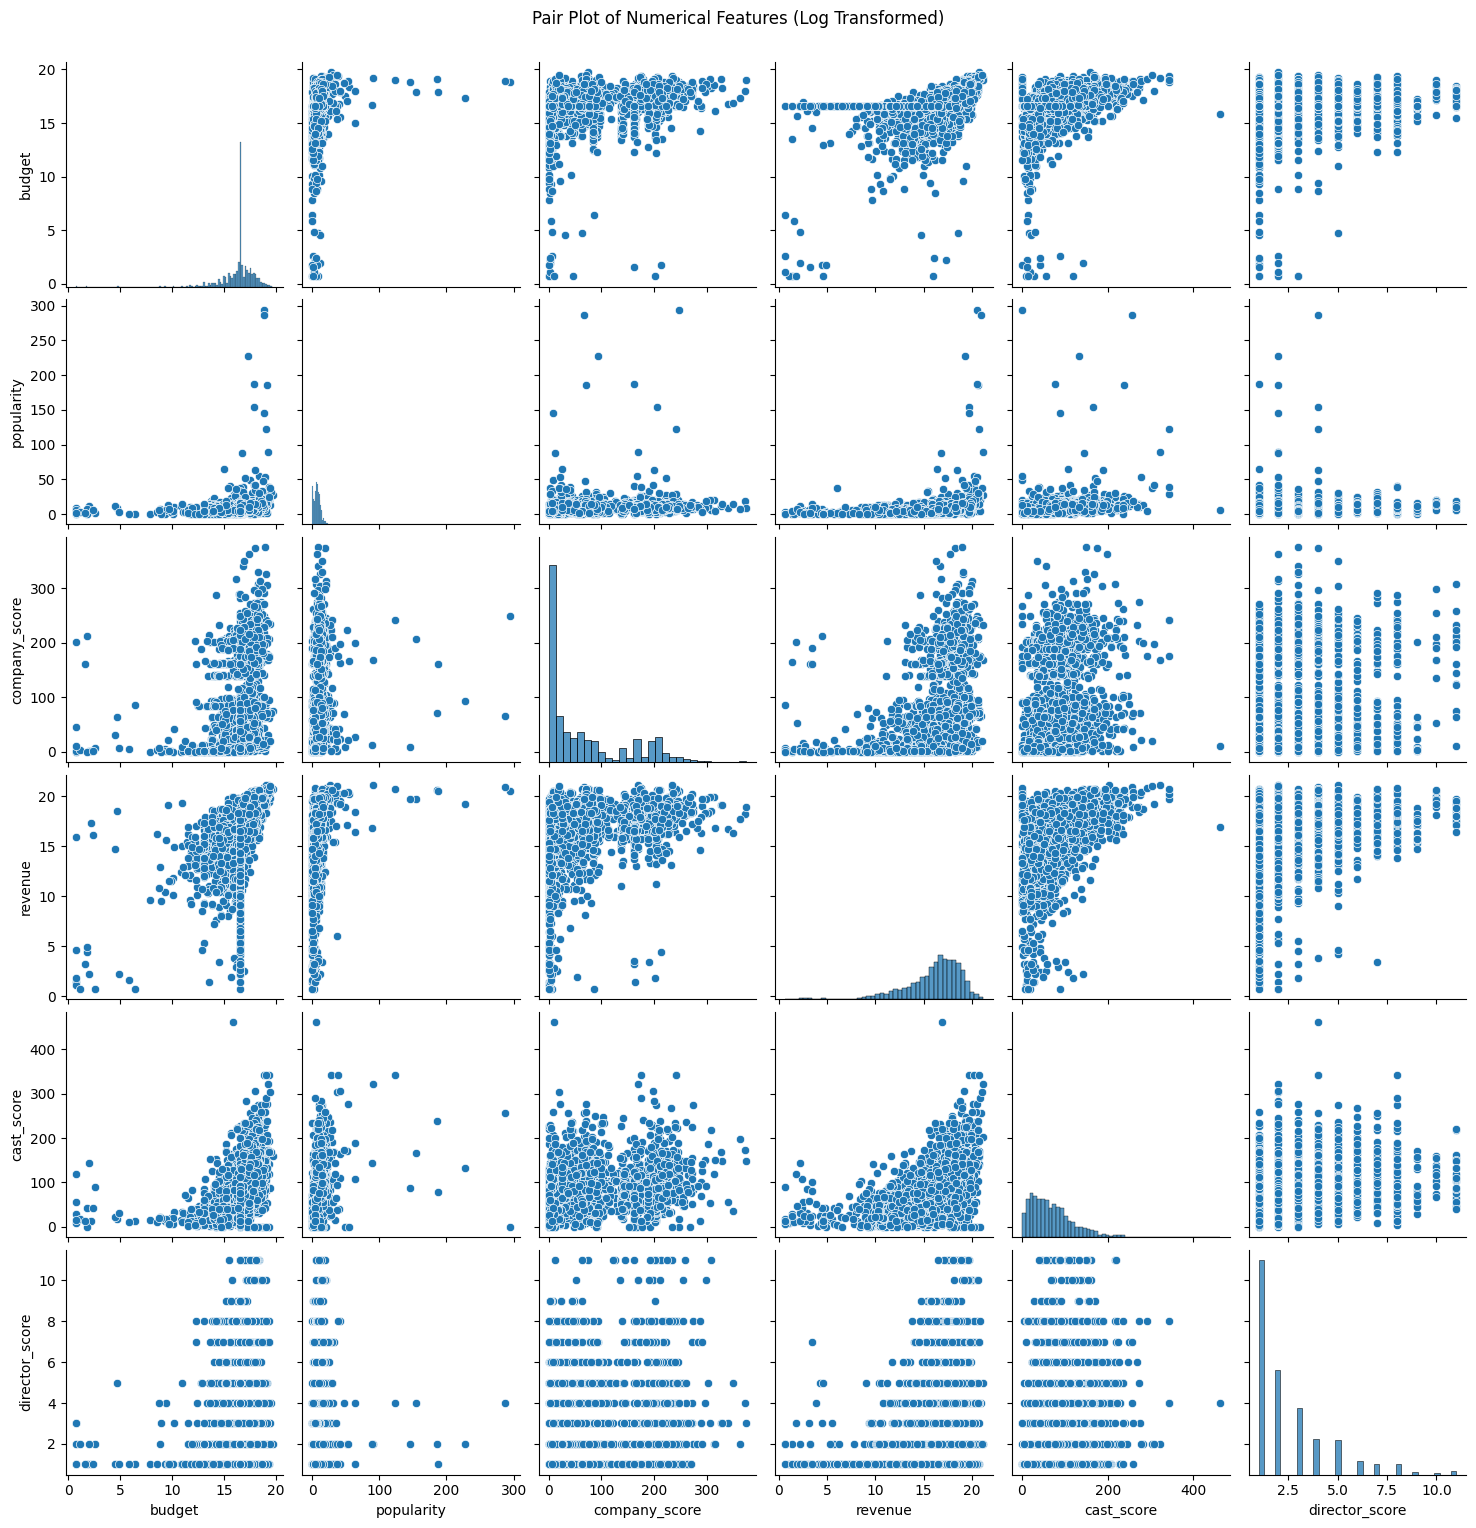

In [381]:
df_log = df[subset_cols].copy()
df_log['revenue'] = np.log1p(df_log['revenue'])
df_log['budget'] = np.log1p(df_log['budget'])

sns.pairplot(df_log)
plt.suptitle("Pair Plot of Numerical Features (Log Transformed)", y=1.02)
plt.show()

# feature engineering

## feature transformation

In [382]:
df['runtime'] = df['runtime'].replace(0, np.nan)
skewness = df[num_cols].skew()

print(skewness)

budget                  3.365873
popularity             14.377407
runtime                 1.662032
revenue                 4.542285
overview_length         1.148699
genre_count             0.496423
overview_word_count     1.145058
company_score           1.106804
top_company_score       1.343177
director_score          1.693568
keyword_score           1.906456
cast_score              1.344278
director_score          1.693568
dtype: float64


In [383]:
df['log_budget'] = np.log1p(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])
df['log_popularity'] = np.log1p(df['popularity'])
df['runtime_log'] = np.log1p(df['runtime'])
df['log_overview_length']=np.log1p(df['overview_length'])
df['log_overview_word_count']=np.log1p(df['overview_word_count'])
df['log_top_company_score']=np.log1p(df['top_company_score'])
df['log_keyword_score'] = np.log1p(df['keyword_score'])
df['log_director_score'] = np.log1p(df['director_score'])
df['log_company_score'] = np.log1p(df['company_score'])
df['sqrt_cast_score'] = np.sqrt(df['cast_score'])

In [384]:
log_num_cols=['log_budget','log_revenue','log_popularity','runtime_log','log_overview_length','log_overview_word_count','log_top_company_score','log_keyword_score','log_director_score','log_company_score','sqrt_cast_score']
skewness = df[log_num_cols].skew()

print(skewness)

log_budget                -3.776551
log_revenue               -1.650536
log_popularity            -0.423864
runtime_log                0.001568
log_overview_length       -2.062791
log_overview_word_count   -0.955233
log_top_company_score      1.312198
log_keyword_score         -1.170916
log_director_score         0.777065
log_company_score         -0.274673
sqrt_cast_score            0.187525
dtype: float64


In [385]:
cols = ['log_budget', 'log_popularity','log_overview_length','log_overview_word_count','log_top_company_score','log_keyword_score','log_company_score', 'log_revenue']

for col in cols:
    lower = df[col].quantile(0.1)
    upper = df[col].quantile(0.90)
    df[col] = df[col].clip(lower, upper)

In [386]:
skewness = df[log_num_cols].skew()

print(skewness)

log_budget                -0.376594
log_revenue               -0.543710
log_popularity            -0.664516
runtime_log                0.001568
log_overview_length       -0.248067
log_overview_word_count   -0.263864
log_top_company_score      1.299559
log_keyword_score         -0.919598
log_director_score         0.777065
log_company_score         -0.199300
sqrt_cast_score            0.187525
dtype: float64


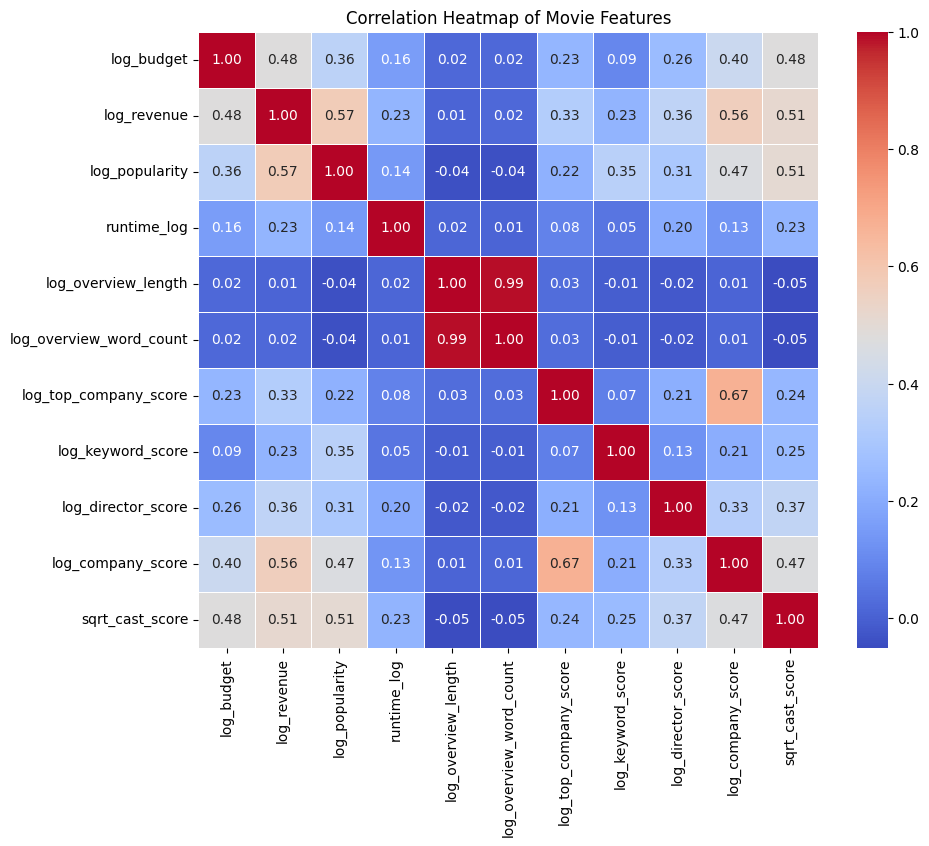

In [387]:
cols = log_num_cols

# Compute correlation matrix
corr_matrix = df[cols].corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Movie Features")
plt.show()

In [388]:
#cat col trans formation
target = 'log_revenue'

In [389]:
for col in cat_cols:
    pivot = pd.pivot_table(
        df,
        values=target,
        index=col,
        aggfunc='mean'
    )
    print(f"\nPivot for {col}:\n", pivot)


Pivot for has_collection:
                 log_revenue
has_collection             
0                 15.869164
1                 17.431458

Pivot for has_homepage:
               log_revenue
has_homepage             
0               15.950866
1               16.689260

Pivot for is_english:
             log_revenue
is_english             
0             14.997617
1             16.379468

Pivot for original_language_es:
                       log_revenue
original_language_es             
0                       16.204948
1                       14.722978

Pivot for original_language_fr:
                       log_revenue
original_language_fr             
0                       16.230289
1                       14.438628

Pivot for original_language_hi:
                       log_revenue
original_language_hi             
0                       16.185937
1                       16.026606

Pivot for original_language_other:
                          log_revenue
original_language_other   

In [390]:
for col in cat_cols:
    corr, p = pearsonr(df[col], df['log_revenue'])

    print("Correlation:",col, corr)
    print("P-value:", p)

Correlation: has_collection 0.2824737329438074
P-value: 3.770461888267677e-56
Correlation: has_homepage 0.15469915585650235
P-value: 1.581358714477843e-17
Correlation: is_english 0.21726905971199204
P-value: 2.2041623459187013e-33
Correlation: original_language_es -0.07942414997770858
P-value: 1.3287975463243132e-05
Correlation: original_language_fr -0.12855733830595992
P-value: 1.5742496102595097e-12
Correlation: original_language_hi -0.008440692100309968
P-value: 0.6439871587528618
Correlation: original_language_other -0.12180993676148526
P-value: 2.1720448138065792e-11
Correlation: original_language_ru -0.10834293774543476
P-value: 2.6940192895275894e-09
Correlation: is_top_company 0.3298565884433185
P-value: 4.496294513848936e-77
Correlation: usa_produced 0.33119530162559285
P-value: 1.010026751806317e-77
Correlation: has_english 0.24024180345433638
P-value: 1.1994026395642063e-40
Correlation: has_keywords 0.24873104034760254
P-value: 1.5482982666385698e-43


In [391]:
df['movie_age'] = 2026 - df['release_year']
df['movie_age'] = df['movie_age'].clip(lower=0)  # remove negatives
df['movie_age_log'] = np.log1p(df['movie_age'])

In [392]:
df['is_peak_season'] = df['release_month'].isin([5,6,7,11,12]).astype(int)

In [393]:
df['is_friday_release'] = (df['release_dayofweek'] == 4).astype(int)

In [394]:
log_num_cols.extend(cat_cols)

In [395]:
log_num_cols.extend(['movie_age_log','is_peak_season','is_friday_release'])

In [396]:
df = df[log_num_cols]
drop_cols = [
    'original_language_es',
    'original_language_fr',
    'original_language_hi',
    'original_language_ru',
    'original_language_other'
]
df = df.drop(columns=drop_cols)
df.head()

,log_budget,log_revenue,log_popularity,runtime_log,log_overview_length,log_overview_word_count,log_top_company_score,log_keyword_score,log_director_score,log_company_score,...,has_collection,has_homepage,is_english,is_top_company,usa_produced,has_english,has_keywords,movie_age_log,is_peak_season,is_friday_release
0,16.454568,16.326300,2.024905,4.543295,5.049856,3.401197,0.693147,5.429346,1.386294,5.313206,...,1,0,1,1,1,1,1,2.484907,0,1
1,17.504390,18.370959,2.224504,4.736198,5.976351,4.248495,0.000000,3.555348,1.945910,4.143135,...,1,0,1,0,1,1,1,3.135494,0,1
2,15.009433,16.387512,2.717041,4.663439,4.875197,3.091042,0.000000,5.087596,0.693147,3.295837,...,0,1,1,0,1,1,1,2.564949,0,1
3,14.694722,16.588099,1.429099,4.812184,6.228511,4.465908,0.000000,3.912023,0.693147,0.693147,...,0,1,0,0,0,1,1,2.708050,0,1
4,16.588099,15.182615,0.832077,4.779123,5.129899,3.496508,0.000000,1.098612,0.693147,0.693147,...,0,0,0,0,0,0,0,2.890372,0,0


## feature creation

In [397]:
df['budget_popularity'] = df['log_budget'] * df['log_popularity']
df['collection_popularity'] = df['has_collection'] * df['log_popularity']
df['company_director'] = df['log_company_score'] * df['log_director_score']

In [398]:
df.skew()

log_budget                -0.376594
log_revenue               -0.543710
log_popularity            -0.664516
runtime_log                0.001568
log_overview_length       -0.248067
log_overview_word_count   -0.263864
log_top_company_score      1.299559
log_keyword_score         -0.919598
log_director_score         0.777065
log_company_score         -0.199300
sqrt_cast_score            0.187525
has_collection             1.490367
has_homepage               0.795264
is_english                -2.056234
is_top_company             1.295043
usa_produced              -1.222458
has_english               -2.237034
has_keywords              -2.824688
movie_age_log             -2.236005
is_peak_season             0.474356
is_friday_release          0.225531
budget_popularity         -0.493008
collection_popularity      1.671903
company_director           0.861518
dtype: float64

In [399]:
X = df.drop(columns=['log_revenue'])  
y = df['log_revenue']   

In [401]:
X = X.replace([np.inf, -np.inf], np.nan)

X_scaled = X.fillna(X.median())


In [402]:
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

In [403]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [404]:
X_scaled.head()

,log_budget,log_popularity,runtime_log,log_overview_length,log_overview_word_count,log_top_company_score,log_keyword_score,log_director_score,log_company_score,sqrt_cast_score,...,is_top_company,usa_produced,has_english,has_keywords,movie_age_log,is_peak_season,is_friday_release,budget_popularity,collection_popularity,company_director
0,16.454568,2.024905,4.543295,5.049856,3.401197,0.693147,5.429346,1.386294,5.313206,10.049876,...,1,1,1,1,2.484907,0,1,33.318941,2.024905,7.365667
1,17.504390,2.224504,4.736198,5.976351,4.248495,0.000000,3.555348,1.945910,4.143135,9.746794,...,0,1,1,1,3.135494,0,1,38.938587,2.224504,8.062168
2,15.009433,2.717041,4.663439,4.875197,3.091042,0.000000,5.087596,0.693147,3.295837,10.392305,...,0,1,1,1,2.564949,0,1,40.781246,0.000000,2.284500
3,14.694722,1.429099,4.812184,6.228511,4.465908,0.000000,3.912023,0.693147,0.693147,3.316625,...,0,0,1,1,2.708050,0,1,21.000213,0.000000,0.480453
4,16.588099,0.832077,4.779123,5.129899,3.496508,0.000000,1.098612,0.693147,0.693147,2.236068,...,0,0,0,0,2.890372,0,0,13.802582,0.000000,0.480453


# model training

In [405]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [406]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [407]:
y_pred = model.predict(X_test)

In [87]:
# y_pred_log = np.power(y_pred, 1/6)

In [88]:
# y_pred_actual = np.expm1(y_pred)

In [89]:
# y_test_log = np.power(y_test, 1/6)

In [90]:
# y_test_actual = np.expm1(y_test)

In [408]:
# print("Actual:", y_test_actual[:5])
# print("Predicted:", y_pred_actual[:5])

In [409]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.5107220594935913
R² Score: 0.5587696152814499


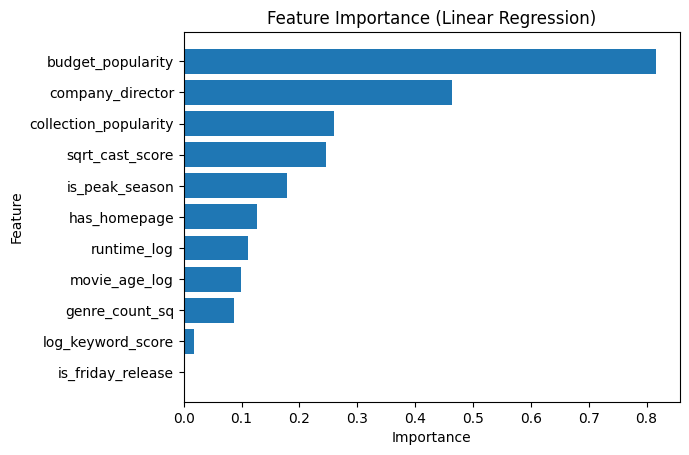

In [93]:
coefficients = model.coef_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': np.abs(coefficients)
})

# Sort
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Linear Regression)")
plt.gca().invert_yaxis()
plt.show()

In [94]:
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(scores.mean())

0.4961809127789409


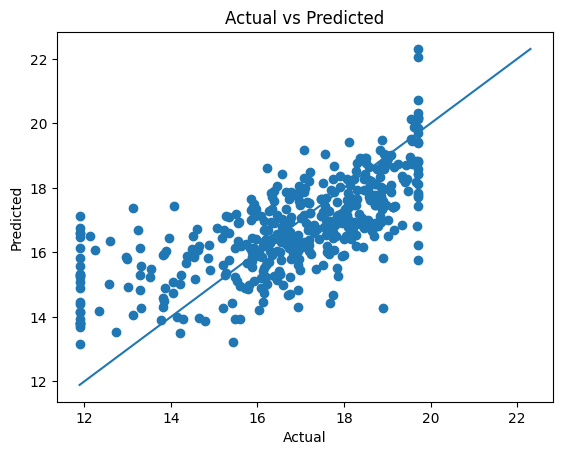

In [95]:
plt.figure()
plt.scatter(y_test, y_pred)

# Diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])  # y = x line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [96]:
top_features = feature_importance['Feature'].head(5)

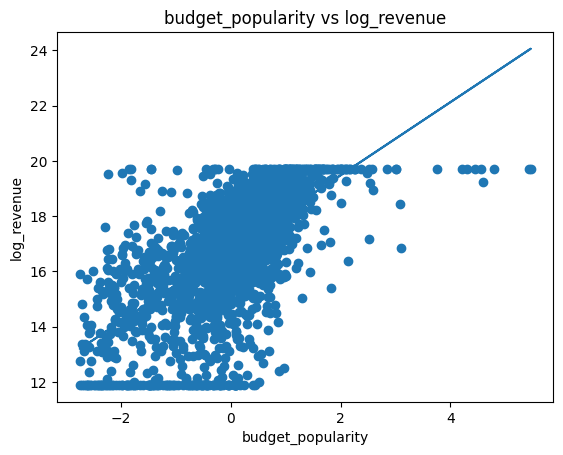

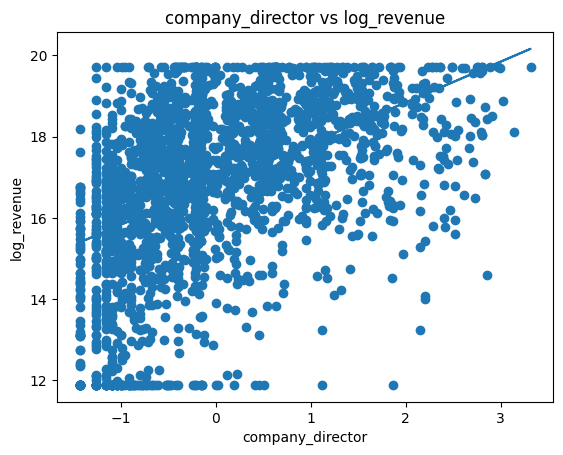

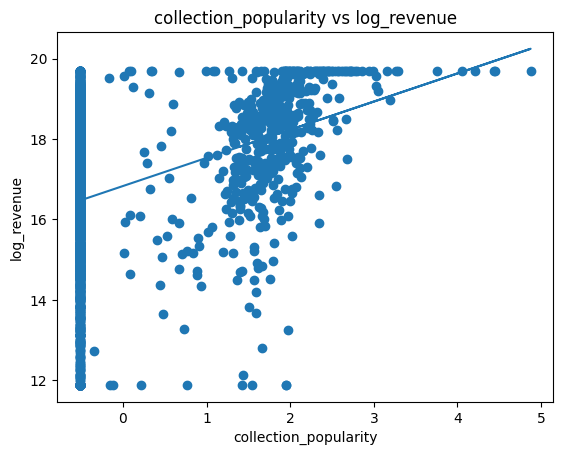

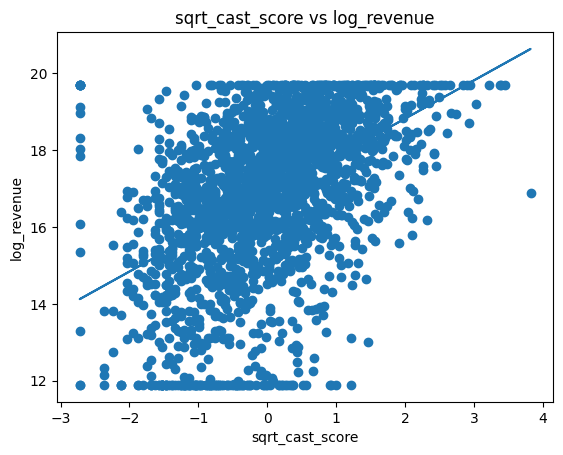

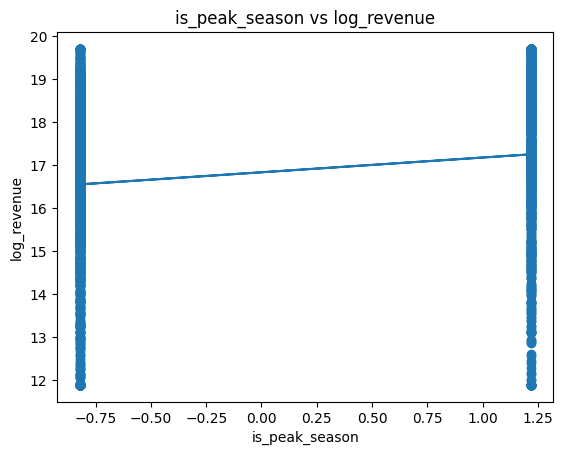

In [97]:
for feature in top_features:
    plt.figure()
    plt.scatter(X_scaled[feature], y)

    # regression line
    z = np.polyfit(X_scaled[feature], y, 1)
    p = np.poly1d(z)

    plt.plot(X_scaled[feature], p(X_scaled[feature]))

    plt.xlabel(feature)
    plt.ylabel("log_revenue")
    plt.title(f"{feature} vs log_revenue")

    plt.show()

In [98]:
X_train_top_feat=X_train[top_features]
X_test_top_feat=X_test[top_features]
X_train_top_feat.head()

,budget_popularity,company_director,collection_popularity,sqrt_cast_score,is_peak_season
552,2.011974,1.451182,2.611081,0.274117,1.216851
765,-0.019545,-0.617893,1.521874,-0.675160,1.216851
479,1.487942,0.671729,-0.517248,1.721803,-0.821794
256,0.348546,2.735001,-0.517248,0.233903,-0.821794
1488,-0.895039,-1.034810,1.198591,-1.523359,1.216851


In [99]:
model_top_feat=LinearRegression()
model_top_feat.fit(X_train_top_feat, y_train)

LinearRegression()

In [100]:
y_pred_top_feat = model_top_feat.predict(X_test_top_feat)

In [101]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_top_feat))
r2 = r2_score(y_test, y_pred_top_feat)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.5257778496283807
R² Score: 0.4600603101155407


In [102]:
X1=X[top_features]

scores = cross_val_score(model_top_feat, X1, y, cv=5, scoring='r2')
print(scores.mean())

0.4904275640560757


In [103]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor( n_estimators=300,
    max_depth=6,
    min_samples_split=16,
    min_samples_leaf=12,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [104]:
y_train_pred = model.predict(X_train)
rmse = np.sqrt(mean_squared_error( y_train,y_train_pred))
r2 = r2_score(y_train, y_train_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.295758109133134
R² Score: 0.6075032940334401


In [105]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.489233878254711
R² Score: 0.485614810181067


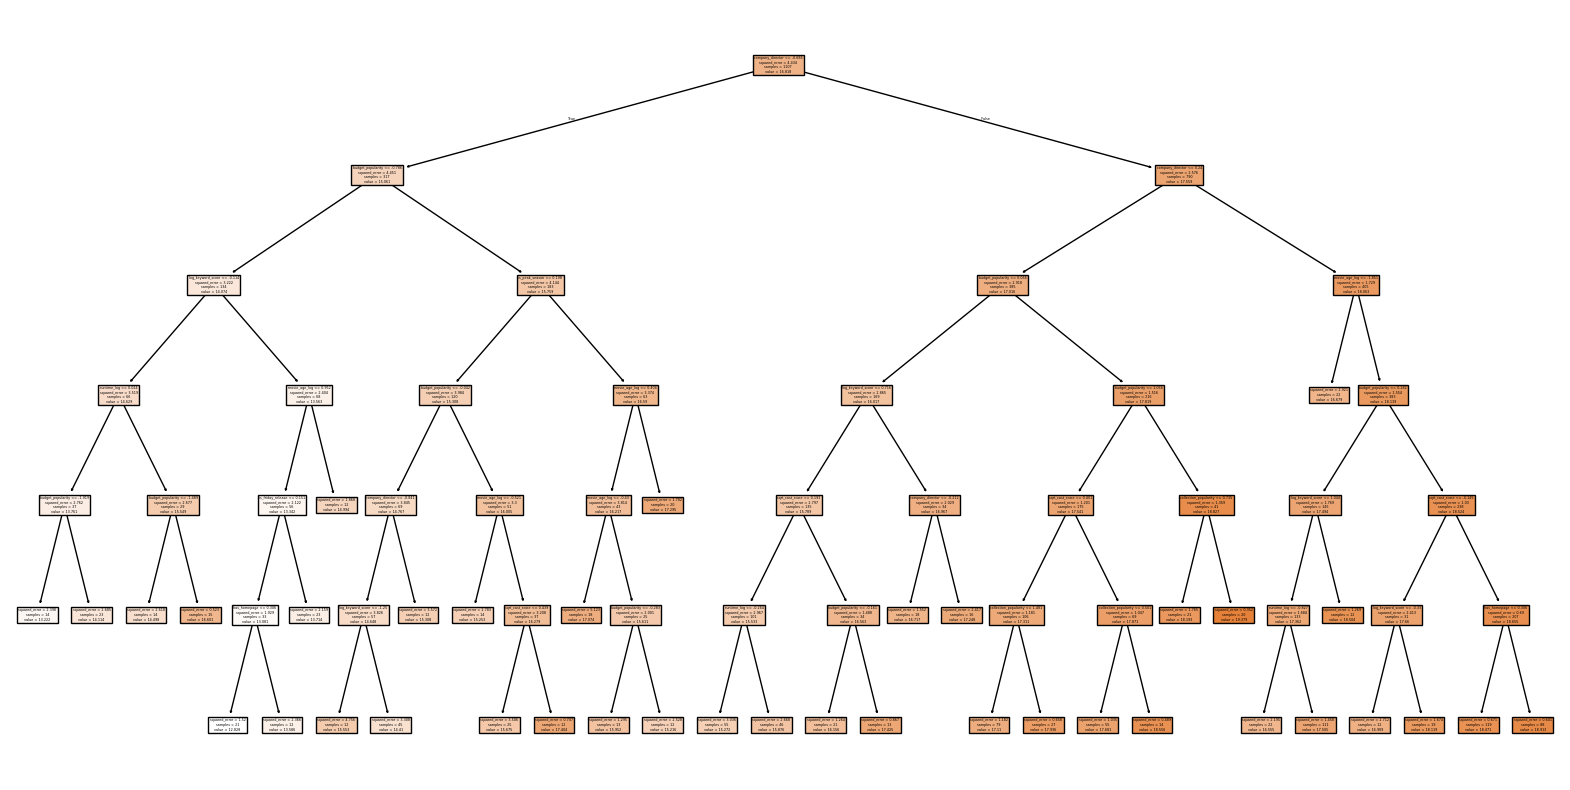

In [106]:
# pick one tree
tree = model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X.columns, filled=True)
plt.show()

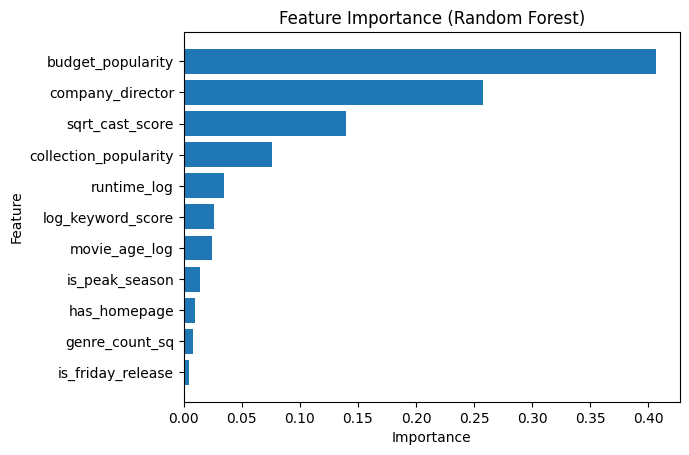

In [107]:
# Get importance
importances = model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

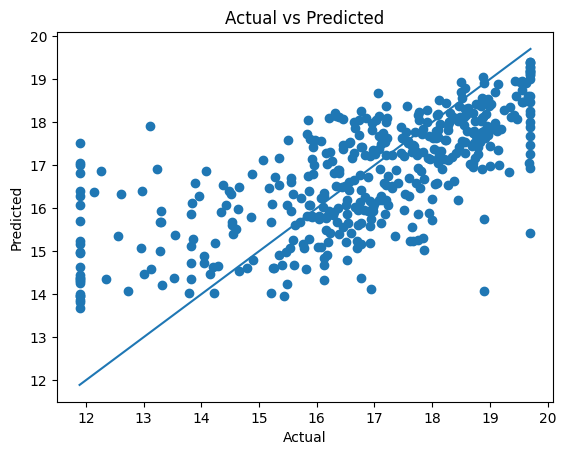

In [108]:
plt.figure()
plt.scatter(y_test, y_pred)

# Diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])  # y = x line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [109]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=150,
    learning_rate=0.02,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [110]:
y_train_pred = model.predict(X_train)
rmse = np.sqrt(mean_squared_error( y_train,y_train_pred))
r2 = r2_score(y_train, y_train_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.3081752136098372
R² Score: 0.5999447466488343


In [111]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.4709788897337541
R² Score: 0.4981481591764664


<Figure size 500000x500000 with 0 Axes>

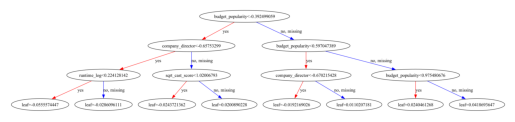

In [112]:
from xgboost import plot_tree
# pick one tree
plt.figure(figsize=(5000, 5000))
plot_tree(model, num_trees=0)  # first tree
plt.show()

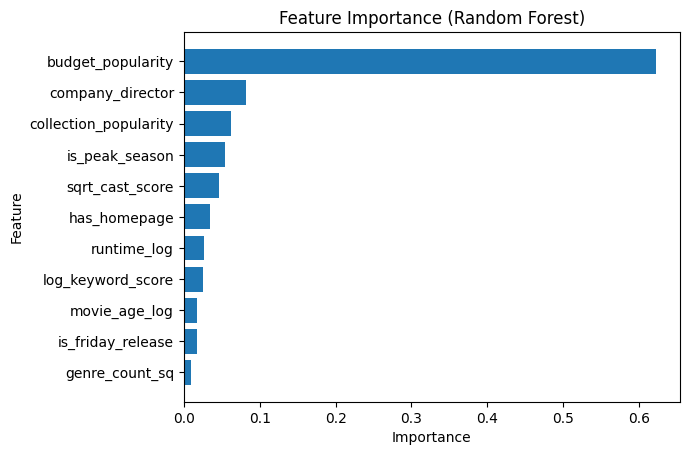

In [501]:
# Get importance
importances = model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

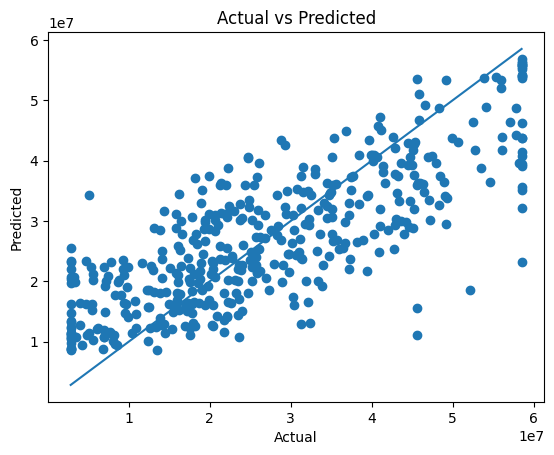

In [502]:
plt.figure()
plt.scatter(y_test, y_pred)

# Diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])  # y = x line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [503]:
from sklearn.svm import SVR

model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [504]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 15758930.315361682
R² Score: -0.003564839966793354


## base models
random forest, xgboost